# Employee Churn Prediction — Ensemble Learning
### Random Forest  ·  XGBoost  ·  Stacking Classifier
---
*10,000 employee records | 21 features | 20% churn rate | Realistic HR-driven patterns*


## 1. Problem Statement & Business Need

**What is employee churn?**
Employee churn (voluntary attrition) is when an employee chooses to leave the organisation.

**Business Goal:**
Identify at-risk employees *before* they resign — so HR and line managers can intervene
with the right action: a salary review, flexible working, a promotion, or simply a conversation.


---
## 2. Metrics for Evaluation

The dataset is imbalanced (80% retained, 20% churned). Accuracy alone is deceptive —
a model that always predicts "stays" hits 80% accuracy without learning anything useful.

| Metric | Why it matters |
|---|---|
| **ROC-AUC** | Primary. Measures how well the model ranks churners above retained employees. |
| **Recall (Churn)** | % of actual leavers we caught. Missing a leaver = full replacement cost. |
| **Precision (Churn)** | % of flagged employees who actually left. Low = wasted HR intervention effort. |
| **F1 (Churn)** | Balance of Precision and Recall for the minority class. |

> In HR, missing a leaver (false negative) is typically more costly than a false alarm.
> We optimise for Recall without letting Precision collapse entirely.


---
## 3. Setup & Data Loading

In [1]:
# Install required libraries
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, precision_score, recall_score, f1_score,
                              log_loss)
from xgboost import XGBClassifier

TEAL, ORANGE, RED, MINT, PURPLE = '#1C7293','#E07B39','#E63946','#2EC4B6','#7B2D8B'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8FAFB',
                     'axes.spines.top':False,'axes.spines.right':False,'font.size':11})

df = pd.read_csv('employee_churn_dataset.csv')
print(f"Shape         : {df.shape}")
print(f"Churn rate    : {df['Churn'].mean():.1%}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape         : (10000, 22)
Churn rate    : 20.0%
Missing values: 0


,Employee ID,Age,Gender,Education Level,Marital Status,Tenure,Job Role,Department,Salary,Work Location,...,Training Hours,Promotions,Overtime Hours,Satisfaction Level,Work-Life Balance,Average Monthly Hours Worked,Absenteeism,Distance from Home,Manager Feedback Score,Churn
0,E00001,50,Male,Bachelor's,Married,5,Analyst,Marketing,93422,Remote,...,35,0,16,0.03,Poor,155,14,15,7.9,1
1,E00002,36,Male,Bachelor's,Married,4,Manager,Sales,44589,On-site,...,1,0,12,0.39,Average,162,2,8,5.2,0
2,E00003,29,Male,Bachelor's,Married,3,Sales,IT,56768,Hybrid,...,41,0,2,0.62,Poor,243,6,21,6.3,0
3,E00004,42,Male,Bachelor's,Single,12,Analyst,Sales,79009,On-site,...,33,0,8,0.73,Good,291,11,25,7.4,0
4,E00005,40,Other,Bachelor's,Married,1,Sales,HR,81982,On-site,...,30,0,13,0.52,Average,272,3,1,4.1,0


---
## 4. Feature Dictionary

| Column | Type | Description | HR Relevance |
|---|---|---|---|
| `Employee ID` | ID | Unique identifier | Drop before modelling |
| `Age` | Numeric | Employee age (22–59) | Younger employees job-hop more |
| `Gender` | Categorical | Male / Female / Other | Proxy for pay equity gaps |
| `Education Level` | Categorical | High School → PhD | Higher education = more external options |
| `Marital Status` | Categorical | Single / Married / Divorced | Singles have fewer location constraints |
| `Tenure` | Numeric | Years at company | Very new and mid-career employees churn most |
| `Job Role` | Categorical | Analyst / Developer / Manager / Sales | Market demand varies by role |
| `Department` | Categorical | IT / HR / Sales / Marketing | Culture & growth differ by dept |
| `Salary` | Numeric | Annual salary (USD) | Below-market pay is the #1 stated exit reason |
| `Work Location` | Categorical | On-site / Hybrid / Remote | Flexibility is a top retention lever |
| `Performance Rating` | Numeric (1–5) | Manager score | High performers have more outside options |
| `Projects Completed` | Numeric | Total projects | Workload and contribution proxy |
| `Training Hours` | Numeric | Hours of training | Low investment in growth = disengagement signal |
| `Promotions` | Binary (0/1) | Promoted last year? | One of the strongest retention actions |
| `Overtime Hours` | Numeric | Monthly OT hours | Burnout driver — excess OT precedes exits |
| `Satisfaction Level` | Numeric (0–1) | Self-reported score | **Strongest predictor** — the most direct exit signal |
| `Work-Life Balance` | Categorical | Poor → Excellent | Tied to burnout and long-term loyalty |
| `Average Monthly Hours` | Numeric | Total hours/month | Combined with OT, reveals true workload |
| `Absenteeism` | Numeric | Absent days/year | Rising absenteeism often precedes resignation |
| `Distance from Home` | Numeric | Commute distance (km) | Daily friction for on-site workers |
| `Manager Feedback Score` | Numeric (1–10) | Relationship quality | People leave managers, not companies |
| `Churn` | **Target** | 1 = left, 0 = stayed | What we predict |


---
## 5. Data Overview

In [3]:
print(df.describe(include='number').round(2).to_string())

            Age    Tenure     Salary  Performance Rating  Projects Completed  Training Hours  Promotions  Overtime Hours  Satisfaction Level  Average Monthly Hours Worked  Absenteeism  Distance from Home  Manager Feedback Score    Churn
count  10000.00  10000.00   10000.00            10000.00            10000.00        10000.00     10000.0        10000.00            10000.00                      10000.00     10000.00            10000.00                10000.00  10000.0
mean      40.56      6.98   89772.75                3.03               24.50           49.72         0.1           24.25                0.49                        224.54         9.47               24.49                    5.57      0.2
std       10.88      4.30   34469.81                1.41               14.44           28.93         0.3           14.48                0.29                         43.63         5.76               14.51                    2.60      0.4
min       22.00      0.00   30010.00                

---
## 6. Exploratory Data Analysis

Only plots that reveal genuinely actionable patterns.


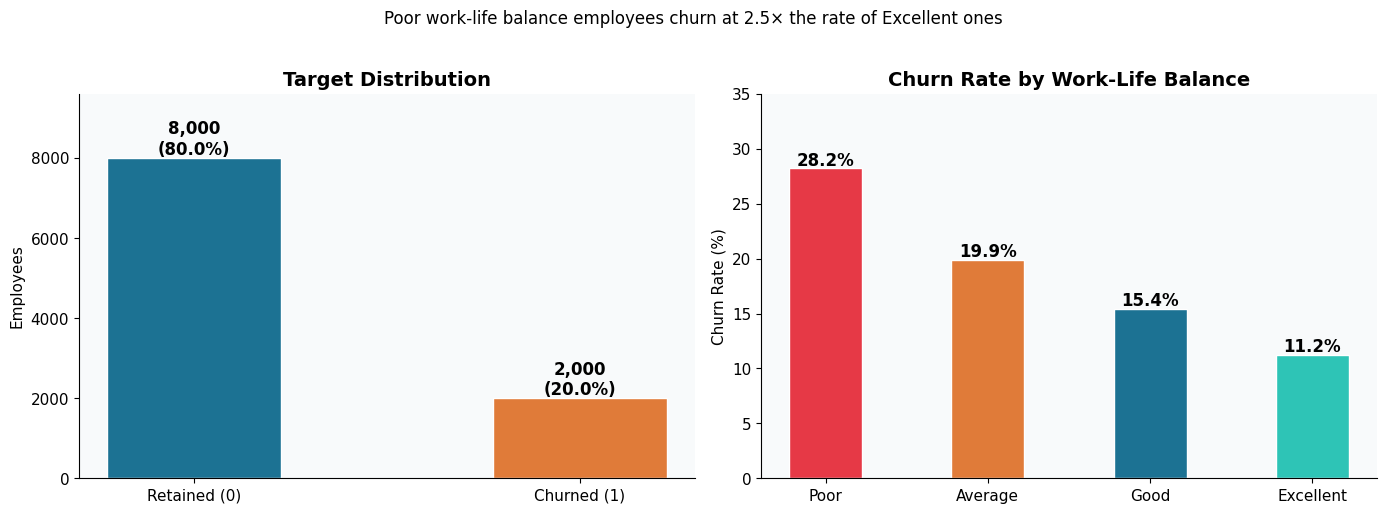

In [4]:
# ── Plot 1: Churn distribution + Work-Life Balance ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn counts
counts = df['Churn'].value_counts().sort_index()
bars = axes[0].bar(['Retained (0)','Churned (1)'], counts.values,
                    color=[TEAL, ORANGE], edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                 f'{val:,}\n({val/len(df):.1%})',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Employees')
axes[0].set_ylim(0, counts.max()*1.2)

# WLB churn rates
order = ['Poor','Average','Good','Excellent']
wlb_cr = df.groupby('Work-Life Balance')['Churn'].mean().reindex(order)*100
bars2 = axes[1].bar(order, wlb_cr.values,
                    color=[RED,ORANGE,TEAL,MINT], edgecolor='white', width=0.45)
for bar, val in zip(bars2, wlb_cr.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Rate by Work-Life Balance', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 35)

plt.suptitle('Poor work-life balance employees churn at 2.5× the rate of Excellent ones',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

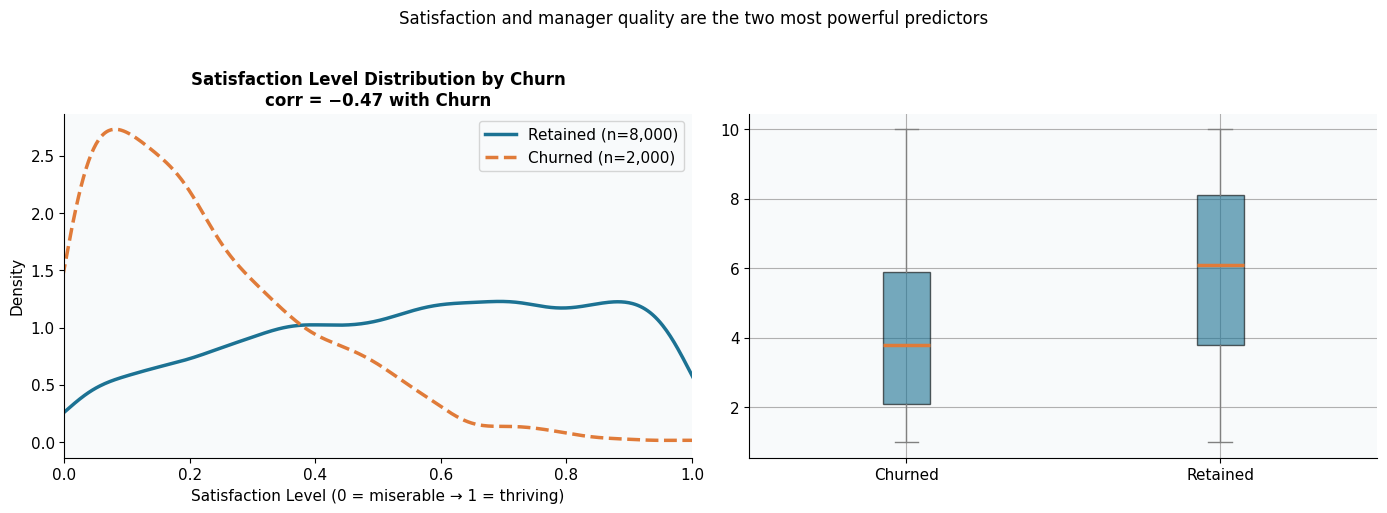

Churned employees avg satisfaction : 0.222
Retained employees avg satisfaction: 0.563

Churned avg manager score : 4.21
Retained avg manager score: 5.9


In [5]:
# ── Plot 2: Satisfaction Level & Manager Feedback — the core signals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction KDE
for label, color, ls in [(0, TEAL,'-'), (1, ORANGE,'--')]:
    subset = df[df['Churn']==label]['Satisfaction Level']
    subset.plot.kde(ax=axes[0], color=color, lw=2.5, ls=ls,
                    label=f"{'Retained' if label==0 else 'Churned'} (n={len(subset):,})")
axes[0].set_xlabel('Satisfaction Level (0 = miserable → 1 = thriving)')
axes[0].set_ylabel('Density')
axes[0].set_title('Satisfaction Level Distribution by Churn\ncorr = −0.47 with Churn',
                  fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].set_xlim(0,1)

# Manager score box
df_tmp = df.copy()
df_tmp['Status'] = df_tmp['Churn'].map({0:'Retained',1:'Churned'})
df_tmp.boxplot(column='Manager Feedback Score', by='Status', ax=axes[1],
               patch_artist=True, boxprops=dict(facecolor=TEAL, alpha=0.6),
               medianprops=dict(color=ORANGE, linewidth=2.5),
               whiskerprops=dict(color='grey'), capprops=dict(color='grey'))
axes[1].set_title('Manager Feedback Score by Churn\ncorr = −0.26 with Churn',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(''); plt.sca(axes[1]); plt.title('')

plt.suptitle('Satisfaction and manager quality are the two most powerful predictors',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Churned employees avg satisfaction :",
      df[df['Churn']==1]['Satisfaction Level'].mean().round(3))
print("Retained employees avg satisfaction:",
      df[df['Churn']==0]['Satisfaction Level'].mean().round(3))
print("\nChurned avg manager score :",
      df[df['Churn']==1]['Manager Feedback Score'].mean().round(2))
print("Retained avg manager score:",
      df[df['Churn']==0]['Manager Feedback Score'].mean().round(2))

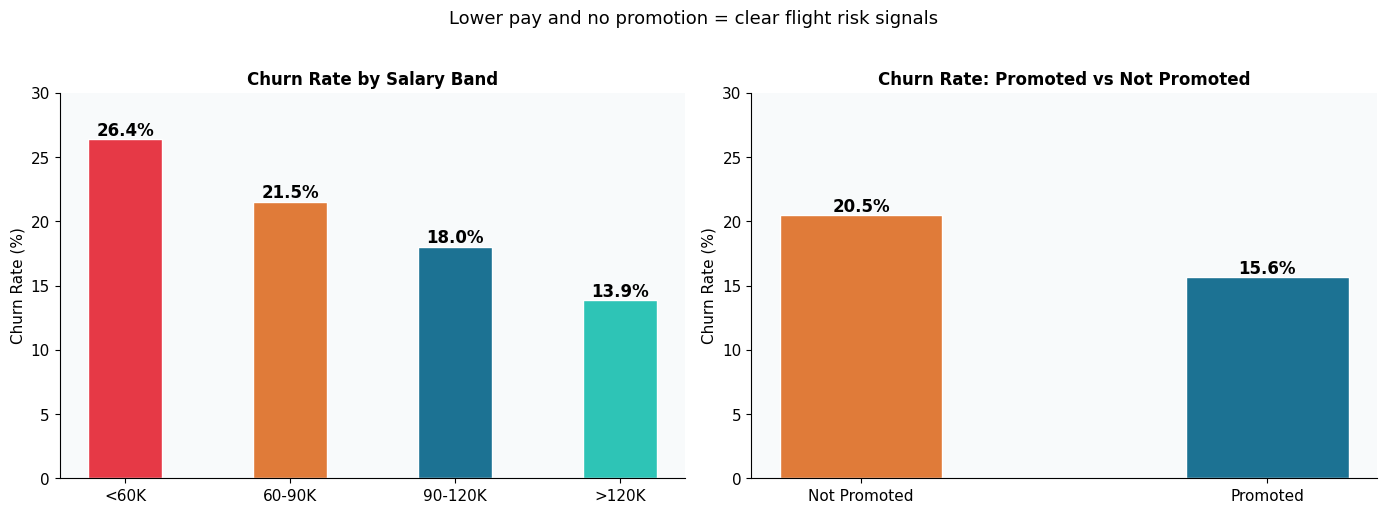

In [6]:
# ── Plot 3: Salary band & Promotions ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Salary Band'] = pd.cut(df['Salary'],
    bins=[0,60000,90000,120000,160000],
    labels=['<60K','60-90K','90-120K','>120K'])

sal_cr = df.groupby('Salary Band',observed=True)['Churn'].mean()*100
axes[0].bar(sal_cr.index, sal_cr.values,
            color=[RED,ORANGE,TEAL,MINT], edgecolor='white', width=0.45)
for i,(idx,val) in enumerate(sal_cr.items()):
    axes[0].text(i, val+0.3, f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')
axes[0].set_title('Churn Rate by Salary Band', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)'); axes[0].set_ylim(0,30)

prom_cr = df.groupby('Promotions')['Churn'].mean()*100
axes[1].bar(['Not Promoted','Promoted'], prom_cr.values,
            color=[ORANGE,TEAL], edgecolor='white', width=0.4)
for i,val in enumerate(prom_cr.values):
    axes[1].text(i, val+0.3, f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')
axes[1].set_title('Churn Rate: Promoted vs Not Promoted',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)'); axes[1].set_ylim(0,30)

df.drop(columns=['Salary Band'], inplace=True)
plt.suptitle('Lower pay and no promotion = clear flight risk signals',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

Six new features grounded in HR research — signals a good analyst would notice.


In [7]:
data = df.copy()

# ── 1. burnout_risk: the trifecta of disengagement ───────────────
# Overtime + long hours + low satisfaction = classic burnout pattern
data['burnout_risk'] = (
    (data['Overtime Hours'] > 35) &
    (data['Average Monthly Hours Worked'] > 260) &
    (data['Satisfaction Level'] < 0.3)
).astype(int)
print(f"burnout_risk churn rate  : Flagged={data[data['burnout_risk']==1]['Churn'].mean():.1%}"
      f"  |  Others={data[data['burnout_risk']==0]['Churn'].mean():.1%}")

# ── 2. career_stagnation: long tenure, zero growth ───────────────
data['career_stagnation'] = (
    (data['Tenure'] > 5) & (data['Promotions'] == 0)
).astype(int)
print(f"career_stagnation churn  : Flagged={data[data['career_stagnation']==1]['Churn'].mean():.1%}"
      f"  |  Others={data[data['career_stagnation']==0]['Churn'].mean():.1%}")

# ── 3. disengagement_score: composite soft signal ────────────────
wlb_num = data['Work-Life Balance'].map({'Poor':0,'Average':0.33,'Good':0.67,'Excellent':1})
mgr_norm = data['Manager Feedback Score'] / 10
data['disengagement_score'] = (
    (1 - data['Satisfaction Level']) * 0.50 +
    (1 - mgr_norm)                  * 0.30 +
    (1 - wlb_num)                   * 0.20
).round(4)
print(f"disengagement_score mean : Churned={data[data['Churn']==1]['disengagement_score'].mean():.3f}"
      f"  |  Retained={data[data['Churn']==0]['disengagement_score'].mean():.3f}")

# ── 4. commute_stress: distance × location type ──────────────────
loc_w = data['Work Location'].map({'On-site':1.0,'Hybrid':0.5,'Remote':0.0})
data['commute_stress'] = (data['Distance from Home'] * loc_w).round(2)

# ── 5. salary_vs_performance: overpaying or underpaying? ─────────
from sklearn.preprocessing import MinMaxScaler
tmp_sc = MinMaxScaler()
s_norm = tmp_sc.fit_transform(data[['Salary']]).flatten()
p_norm = tmp_sc.fit_transform(data[['Performance Rating']]).flatten()
data['salary_growth_potential'] = (p_norm - s_norm).round(4)  # +ve = performing above pay

# ── 6. productivity_rate: projects per year of tenure ────────────
data['productivity_rate'] = (
    data['Projects Completed'] / data['Tenure'].replace(0, 0.5)
).round(2)

# ── Derived helpers used above ────────────────────────────────────
data['wlb_numeric'] = wlb_num
data['manager_norm'] = mgr_norm

print("\n 8 features engineered:")
new = ['burnout_risk','career_stagnation','disengagement_score',
       'commute_stress','salary_growth_potential','productivity_rate',
       'wlb_numeric','manager_norm']
print(f"   {new}")

burnout_risk churn rate  : Flagged=71.0%  |  Others=18.8%
career_stagnation churn  : Flagged=18.5%  |  Others=21.8%
disengagement_score mean : Churned=0.698  |  Retained=0.461

 8 features engineered:
   ['burnout_risk', 'career_stagnation', 'disengagement_score', 'commute_stress', 'salary_growth_potential', 'productivity_rate', 'wlb_numeric', 'manager_norm']


---
## 8. Preprocessing

In [8]:
data.drop(columns=['Employee ID'], inplace=True)

le = LabelEncoder()
str_cols = data.select_dtypes(include='object').columns.tolist()
for col in str_cols:
    data[col] = le.fit_transform(data[col].astype(str))
print(f"Encoded: {str_cols}")

X = data.drop(columns=['Churn'])
y = data['Churn']
print(f"\nFeatures: {X.shape[1]}  (original + engineered)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")

Encoded: ['Gender', 'Education Level', 'Marital Status', 'Job Role', 'Department', 'Work Location', 'Work-Life Balance']

Features: 28  (original + engineered)
Train: 8,000  |  Test: 2,000
Train churn rate: 20.0%  |  Test: 20.0%


In [9]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_te, y_proba)
    cv_auc  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='roc_auc').mean()
    print(f"\n{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    print(f"  ROC-AUC (test)      : {auc:.4f}")
    print(f"  ROC-AUC (5-fold CV) : {cv_auc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['Retained','Churned']))
    return {'Model':name,'AUC_test':auc,'AUC_cv':cv_auc,
            'model':model,'proba':y_proba}

---
## 9. Baseline Models — Demonstrating Underfitting and Overfitting

Before diving into tuned ensembles, we establish **why they are needed** by
showing what simpler models do wrong.

| Model | Expected behaviour | Root cause |
|---|---|---|
| **Logistic Regression** | Low train AND test accuracy | Assumes a straight-line boundary — too simple for non-linear churn patterns |
| **Decision Tree (default)** | High train, noticeably lower test | Grows until every training row is memorised — classic overfitting |
| **Decision Tree (tuned)** | Train–test gap closes significantly | Depth and leaf constraints prevent memorisation |

The progression from LR → Default DT → Tuned DT → RF → XGBoost tells the
complete bias-variance story in a single comparison.


In [10]:
# ── Logistic Regression — the underfitting baseline ──────────────
# LR draws a single straight-line boundary through the feature space.
# Our churn data has non-linear interactions (burnout_risk, disengagement_score,
# career_stagnation) that a straight line simply cannot capture.
# Result: train ≈ test accuracy, but both are limited → underfitting.

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state = 42
)

lr_res = evaluate('Logistic Regression', lr,
                  X_train, y_train, X_test, y_test)

print("\n💡 Underfitting signal:")
train_auc = roc_auc_score(y_train, lr.predict_proba(X_train)[:,1])
print(f"   Train AUC : {train_auc:.4f}")
print(f"   Test  AUC : {lr_res['AUC_test']:.4f}")
print(f"   Gap       : {abs(train_auc - lr_res['AUC_test']):.4f}")



  Logistic Regression
  ROC-AUC (test)      : 0.6307
  ROC-AUC (5-fold CV) : 0.6927

              precision    recall  f1-score   support

    Retained       0.81      0.98      0.89      1600
     Churned       0.42      0.05      0.09       400

    accuracy                           0.80      2000
   macro avg       0.61      0.52      0.49      2000
weighted avg       0.73      0.80      0.73      2000


💡 Underfitting signal:
   Train AUC : 0.6748
   Test  AUC : 0.6307
   Gap       : 0.0441


In [11]:
# ── Decision Tree (default) — the overfitting example ────────────
# No depth constraint → grows until every training leaf is pure.
# On 8,000 training rows with 28 features this creates hundreds of
# very specific rules that only hold for the training data.
# Result: train accuracy near 100%, test accuracy noticeably lower → overfitting.

from sklearn.tree import DecisionTreeClassifier

dt_default = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42
    # max_depth intentionally not set → unlimited growth
)

dt_default_res = evaluate('Decision Tree (Default)', dt_default,
                           X_train, y_train, X_test, y_test)

print("\n💡 Overfitting signal:")
train_auc_dt = roc_auc_score(y_train, dt_default.predict_proba(X_train)[:,1])
print(f"   Train AUC : {train_auc_dt:.4f}")
print(f"   Test  AUC : {dt_default_res['AUC_test']:.4f}")
gap = train_auc_dt - dt_default_res['AUC_test']
print(f"   Gap       : {gap:.4f}  (large gap = memorising training data)")
print(f"   Tree depth: {dt_default.get_depth()} levels  | Leaves: {dt_default.get_n_leaves():,}")



  Decision Tree (Default)
  ROC-AUC (test)      : 0.7094
  ROC-AUC (5-fold CV) : 0.7127

              precision    recall  f1-score   support

    Retained       0.88      0.91      0.89      1600
     Churned       0.58      0.51      0.54       400

    accuracy                           0.83      2000
   macro avg       0.73      0.71      0.72      2000
weighted avg       0.82      0.83      0.82      2000


💡 Overfitting signal:
   Train AUC : 1.0000
   Test  AUC : 0.7094
   Gap       : 0.2906  (large gap = memorising training data)
   Tree depth: 25 levels  | Leaves: 742


In [12]:
# ── Decision Tree (tuned) — showing the fix ──────────────────────
# Constraining depth and leaf size forces the tree to generalise.
# Still a single tree — diversity and ensemble benefits don't apply —
# but the train-test gap should close significantly.

dt_param_grid = {
    'max_depth':         [3, 5, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      [None, 'sqrt', 'log2'],
    'criterion':         ['gini', 'entropy'],
}

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_distributions = dt_param_grid,
    n_iter      = 20,
    scoring     = 'roc_auc',
    cv          = skf,
    random_state= 42,
    n_jobs      = -1,
    verbose     = 0
)
dt_search.fit(X_train, y_train)

dt_tuned     = dt_search.best_estimator_
dt_tuned_res = evaluate('Decision Tree (Tuned)', dt_tuned,
                         X_train, y_train, X_test, y_test)

print("\n Best DT parameters:")
for p, v in sorted(dt_search.best_params_.items()):
    print(f"   {p:22s}: {v}")

print("\n Overfit reduction summary:")
train_default = roc_auc_score(y_train, dt_default.predict_proba(X_train)[:,1])
train_tuned   = roc_auc_score(y_train, dt_tuned.predict_proba(X_train)[:,1])
print(f"   Default DT — Train: {train_default:.4f}  Test: {dt_default_res['AUC_test']:.4f}  Gap: {train_default-dt_default_res['AUC_test']:.4f}")
print(f"   Tuned   DT — Train: {train_tuned:.4f}  Test: {dt_tuned_res['AUC_test']:.4f}  Gap: {train_tuned-dt_tuned_res['AUC_test']:.4f}")
print(f"   Tree depth reduced: {dt_default.get_depth()} → {dt_tuned.get_depth()}")



  Decision Tree (Tuned)
  ROC-AUC (test)      : 0.9064
  ROC-AUC (5-fold CV) : 0.8912

              precision    recall  f1-score   support

    Retained       0.96      0.76      0.85      1600
     Churned       0.48      0.88      0.62       400

    accuracy                           0.79      2000
   macro avg       0.72      0.82      0.74      2000
weighted avg       0.87      0.79      0.81      2000


 Best DT parameters:
   criterion             : entropy
   max_depth             : 5
   max_features          : None
   min_samples_leaf      : 4
   min_samples_split     : 10

 Overfit reduction summary:
   Default DT — Train: 1.0000  Test: 0.7094  Gap: 0.2906
   Tuned   DT — Train: 0.9171  Test: 0.9064  Gap: 0.0106
   Tree depth reduced: 25 → 5


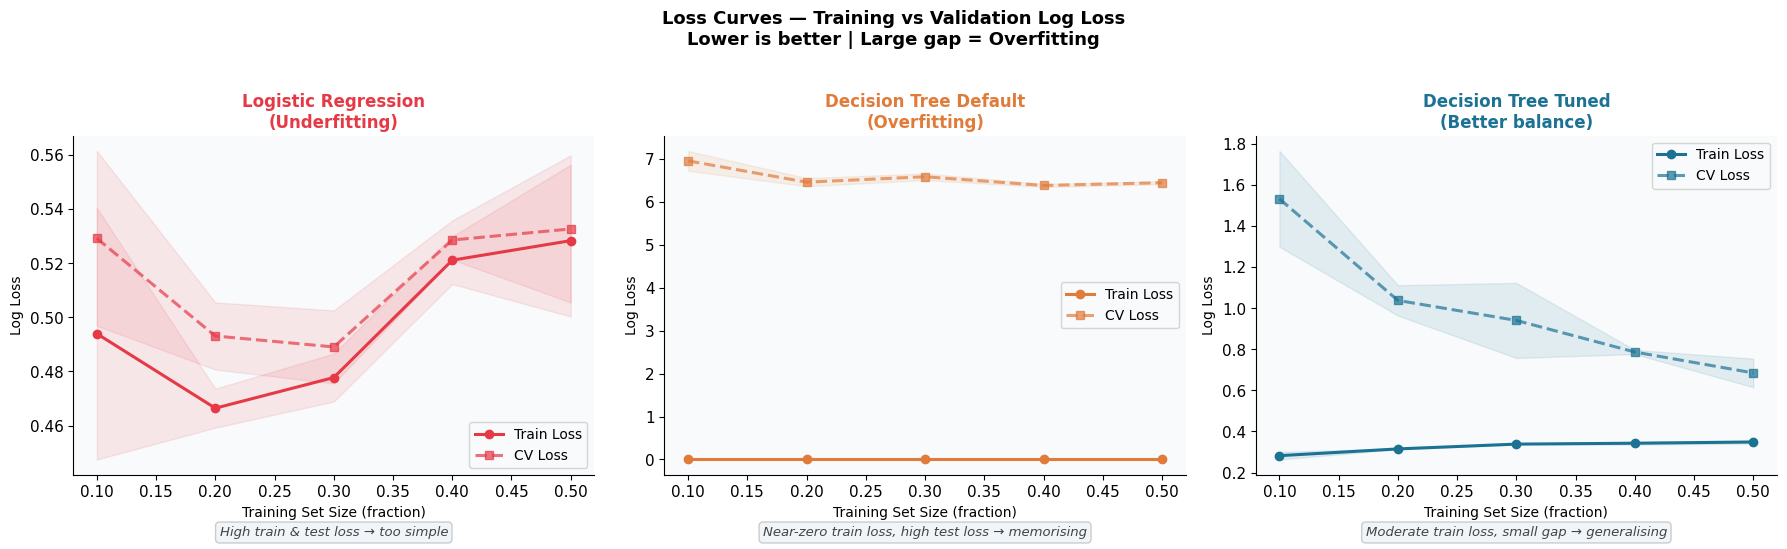

In [13]:
# ── Loss Curves — Training vs Validation Loss ─────────────────────
# Loss curves show the actual error (log loss) rather than ranking performance.
# Lower loss = better fit. Large gap between train and test = overfitting.

from sklearn.model_selection import learning_curve
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Loss Curves — Training vs Validation Log Loss\n'
             'Lower is better | Large gap = Overfitting',
             fontsize=13, fontweight='bold', y=1.02)

models_loss = [
    (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
     'Logistic Regression\n(Underfitting)', RED,
     'High train & test loss → too simple'),
    (DecisionTreeClassifier(class_weight='balanced', random_state=42),
     'Decision Tree Default\n(Overfitting)', ORANGE,
     'Near-zero train loss, high test loss → memorising'),
    (dt_tuned,
     'Decision Tree Tuned\n(Better balance)', TEAL,
     'Moderate train loss, small gap → generalising'),
]

train_sizes = np.linspace(0.20, 1.0, 5)

for ax, (model, title, color, note) in zip(axes, models_loss):
    tr_sizes, tr_scores, cv_scores = learning_curve(
        model, X_train, y_train,
        train_sizes = train_sizes,
        cv          = StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
        scoring     = 'neg_log_loss',
        n_jobs      = -1
    )
    # neg_log_loss returns negative values, so negate to get positive log loss
    tr_mean = -tr_scores.mean(axis=1)
    cv_mean = -cv_scores.mean(axis=1)
    tr_std  = tr_scores.std(axis=1)
    cv_std  = cv_scores.std(axis=1)

    # Convert actual sample counts to fractions
    tr_sizes_frac = tr_sizes / len(X_train)
    
    ax.plot(tr_sizes_frac, tr_mean, 'o-',  color=color,   lw=2.2, label='Train Loss')
    ax.plot(tr_sizes_frac, cv_mean, 's--', color=color,   lw=2.2, label='CV Loss',   alpha=0.7)
    ax.fill_between(tr_sizes_frac, tr_mean-tr_std, tr_mean+tr_std, alpha=0.10, color=color)
    ax.fill_between(tr_sizes_frac, cv_mean-cv_std, cv_mean+cv_std, alpha=0.10, color=color)

    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Training Set Size (fraction)', fontsize=10)
    ax.set_ylabel('Log Loss', fontsize=10)
    ax.legend(fontsize=10)
    ax.text(0.5, -0.18, note, transform=ax.transAxes, ha='center',
            fontsize=9.5, color='#444', style='italic',
            bbox=dict(boxstyle='round', fc='#F0F5FA', ec='#ccc', lw=1))

plt.tight_layout()
plt.show()

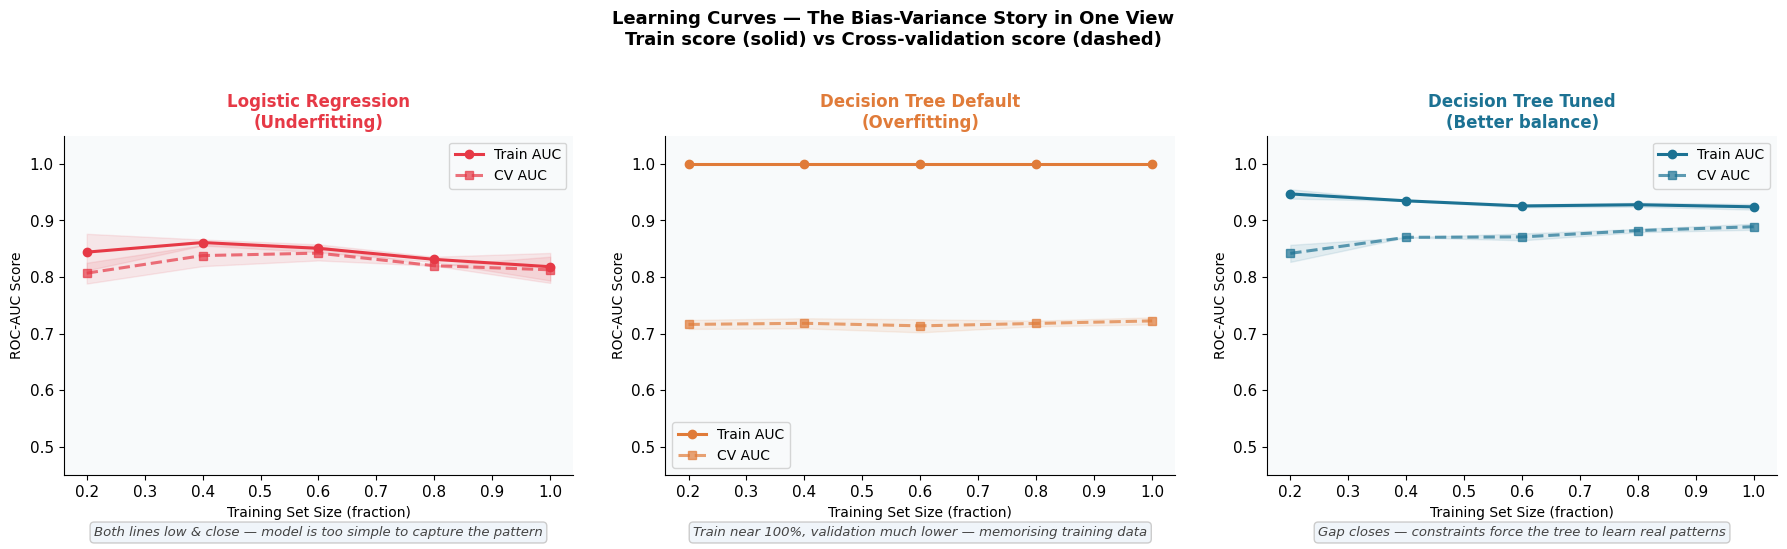

In [14]:
# ── Learning Curves — the clearest visual for under/overfit ──────
# A learning curve plots train vs validation score as training size grows.
#
# Underfitting (LR):      Both lines stay close together but flat/low.
# Overfitting (DT default): Train line is high, validation line much lower.
# Well-fitted (DT tuned): Gap closes as more data is used.

from sklearn.model_selection import learning_curve
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Learning Curves — The Bias-Variance Story in One View\n'
             'Train score (solid) vs Cross-validation score (dashed)',
             fontsize=13, fontweight='bold', y=1.02)

models_lc = [
    (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
     'Logistic Regression\n(Underfitting)', RED,
     'Both lines low & close — model is too simple to capture the pattern'),
    (DecisionTreeClassifier(class_weight='balanced', random_state=42),
     'Decision Tree Default\n(Overfitting)', ORANGE,
     'Train near 100%, validation much lower — memorising training data'),
    (dt_tuned,
     'Decision Tree Tuned\n(Better balance)', TEAL,
     'Gap closes — constraints force the tree to learn real patterns'),
]

train_sizes = np.linspace(0.20, 1.0, 5)

for ax, (model, title, color, note) in zip(axes, models_lc):
    tr_sizes, tr_scores, cv_scores = learning_curve(
        model, X_train, y_train,
        train_sizes = train_sizes,
        cv          = StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
        scoring     = 'roc_auc',
        n_jobs      = -1
    )
    tr_mean = tr_scores.mean(axis=1)
    cv_mean = cv_scores.mean(axis=1)
    tr_std  = tr_scores.std(axis=1)
    cv_std  = cv_scores.std(axis=1)

    # Convert actual sample counts to fractions (multiply by 2 for 2-fold CV to get 0-1 scale)
    tr_sizes_frac = (tr_sizes / len(X_train)) * 2
    
    ax.plot(tr_sizes_frac, tr_mean, 'o-',  color=color,   lw=2.2, label='Train AUC')
    ax.plot(tr_sizes_frac, cv_mean, 's--', color=color,   lw=2.2, label='CV AUC',   alpha=0.7)
    ax.fill_between(tr_sizes_frac, tr_mean-tr_std, tr_mean+tr_std, alpha=0.10, color=color)
    ax.fill_between(tr_sizes_frac, cv_mean-cv_std, cv_mean+cv_std, alpha=0.10, color=color)

    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Training Set Size (fraction)', fontsize=10)
    ax.set_ylabel('ROC-AUC Score', fontsize=10)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=10)
    ax.text(0.5, -0.18, note, transform=ax.transAxes, ha='center',
            fontsize=9.5, color='#444', style='italic',
            bbox=dict(boxstyle='round', fc='#F0F5FA', ec='#ccc', lw=1))

plt.tight_layout()
plt.show()

---

# ENSEMBLE MODELS

## 9. Model 1 — Random Forest

Trains 300 independent trees on random bootstrap samples with random feature subsets.
Excellent baseline — interpretable feature importances, stable, minimal tuning required.


In [15]:
rf = RandomForestClassifier(
    n_estimators=300, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_res = evaluate('Random Forest (300 trees)', rf, X_train, y_train, X_test, y_test)


  Random Forest (300 trees)
  ROC-AUC (test)      : 0.9198
  ROC-AUC (5-fold CV) : 0.9220

              precision    recall  f1-score   support

    Retained       0.93      0.90      0.91      1600
     Churned       0.64      0.74      0.69       400

    accuracy                           0.86      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.87      0.86      0.87      2000



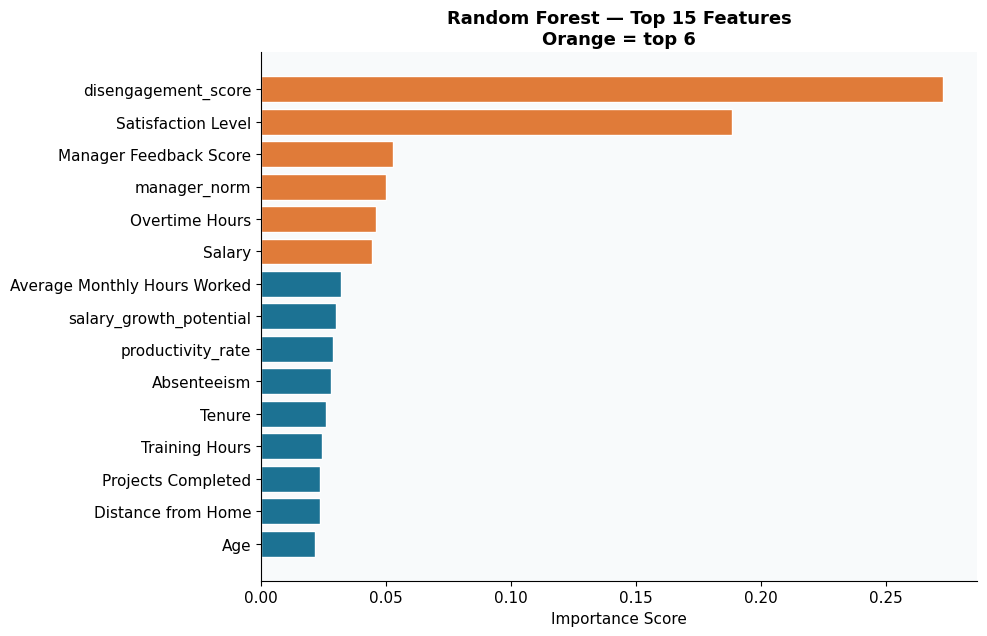

In [16]:
# Feature Importance
imp_df = (pd.DataFrame({'Feature':X_train.columns,'Importance':rf.feature_importances_})
          .sort_values('Importance', ascending=True).tail(15))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=[ORANGE if i>=len(imp_df)-6 else TEAL for i in range(len(imp_df))],
        edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Top 15 Features\n'
             'Orange = top 6',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 9a. Hyperparameter Tuning — Random Forest

**Why tune?**  
The default parameters give a reasonable result but they are not optimised for *this* dataset.  
Hyperparameter tuning systematically searches for the combination that maximises AUC.

**Why RandomizedSearchCV over GridSearchCV?**  
Grid search checks *every* combination (slow).  
Randomised search samples `n_iter` random combinations — it finds near-optimal settings  
in a fraction of the time, which matters on a 10,000-row dataset.

**Scoring: `roc_auc`** — appropriate for our 80/20 imbalanced classes.


In [17]:
# ── Hyperparameter Tuning — Random Forest ────────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Parameter grid — ranges based on RF research and best practices
rf_param_grid = {
    'n_estimators':      [100, 200, 300, 500],    # number of trees
    'max_depth':         [None, 10, 20, 30],       # None = fully grown
    'max_features':      ['sqrt', 'log2'],         # features per split
    'min_samples_split': [2, 5, 10],               # min samples to split a node
    'min_samples_leaf':  [1, 2, 4],                # min samples at a leaf
}

# StratifiedKFold keeps class ratio intact across every fold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator   = RandomForestClassifier(
                      class_weight='balanced',   # handle 80/20 imbalance
                      random_state=42,
                      n_jobs=-1),
    param_distributions = rf_param_grid,
    n_iter      = 10,           # test 30 random combinations
    scoring     = 'roc_auc',   # optimise for AUC (better than accuracy for imbalance)
    cv          = skf,
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)

print("🔍 Searching best RF parameters (15 random combinations × 3-fold CV)...")
rf_search.fit(X_train, y_train)

print(f"\n Best parameters found:")
for param, val in sorted(rf_search.best_params_.items()):
    print(f"   {param:25s}: {val}")
print(f"\n   Best CV AUC (during search): {rf_search.best_score_:.4f}")


🔍 Searching best RF parameters (15 random combinations × 3-fold CV)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Best parameters found:
   max_depth                : 20
   max_features             : log2
   min_samples_leaf         : 2
   min_samples_split        : 2
   n_estimators             : 500

   Best CV AUC (during search): 0.9221


In [18]:
# ── Evaluate tuned RF vs default RF ──────────────────────────────
rf_tuned     = rf_search.best_estimator_
rf_tuned_res = evaluate('Random Forest (Tuned)', rf_tuned,
                         X_train, y_train, X_test, y_test)

# Before / After comparison
print("\n" + "─"*50)
print("  Tuning Impact Summary — Random Forest")
print("─"*50)
print(f"  {'Metric':<22} {'Default':>10} {'Tuned':>10} {'Change':>10}")
print("─"*50)

default_pred = rf.predict(X_test)
tuned_pred   = rf_tuned.predict(X_test)

metrics = [
    ('AUC (test)',       rf_res['AUC_test'],                   rf_tuned_res['AUC_test']),
    ('AUC (5-fold CV)', rf_res['AUC_cv'],                     rf_tuned_res['AUC_cv']),
    ('Recall (Churn)',  recall_score(y_test, default_pred),   recall_score(y_test, tuned_pred)),
    ('F1 (Churn)',      f1_score(y_test, default_pred),       f1_score(y_test, tuned_pred)),
]
for name, def_val, tun_val in metrics:
    delta = tun_val - def_val
    arrow = '↑' if delta > 0 else '↓' if delta < 0 else '→'
    print(f"  {name:<22} {def_val:>10.4f} {tun_val:>10.4f} {arrow} {abs(delta):>7.4f}")
print("─"*50)



  Random Forest (Tuned)
  ROC-AUC (test)      : 0.9228
  ROC-AUC (5-fold CV) : 0.9226

              precision    recall  f1-score   support

    Retained       0.94      0.87      0.91      1600
     Churned       0.61      0.80      0.69       400

    accuracy                           0.86      2000
   macro avg       0.78      0.83      0.80      2000
weighted avg       0.88      0.86      0.86      2000


──────────────────────────────────────────────────
  Tuning Impact Summary — Random Forest
──────────────────────────────────────────────────
  Metric                    Default      Tuned     Change
──────────────────────────────────────────────────
  AUC (test)                 0.9198     0.9228 ↑  0.0030
  AUC (5-fold CV)            0.9220     0.9226 ↑  0.0007
  Recall (Churn)             0.7375     0.7950 ↑  0.0575
  F1 (Churn)                 0.6852     0.6898 ↑  0.0046
──────────────────────────────────────────────────


---
## 10. Model 2 — XGBoost

Sequential boosting: each new tree corrects the residual errors of all previous trees.
Built-in regularisation and class-imbalance handling via `scale_pos_weight`.


In [19]:
scale_pos = (y_train==0).sum() / (y_train==1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80,
    reg_alpha=0.1, reg_lambda=1.5,
    scale_pos_weight=scale_pos, eval_metric='auc',
    random_state=42, verbosity=0)
xgb_res = evaluate('XGBoost (300 trees)', xgb, X_train, y_train, X_test, y_test)

scale_pos_weight = 4.00

  XGBoost (300 trees)
  ROC-AUC (test)      : 0.9261
  ROC-AUC (5-fold CV) : 0.9276

              precision    recall  f1-score   support

    Retained       0.95      0.85      0.90      1600
     Churned       0.58      0.84      0.69       400

    accuracy                           0.85      2000
   macro avg       0.77      0.84      0.79      2000
weighted avg       0.88      0.85      0.86      2000



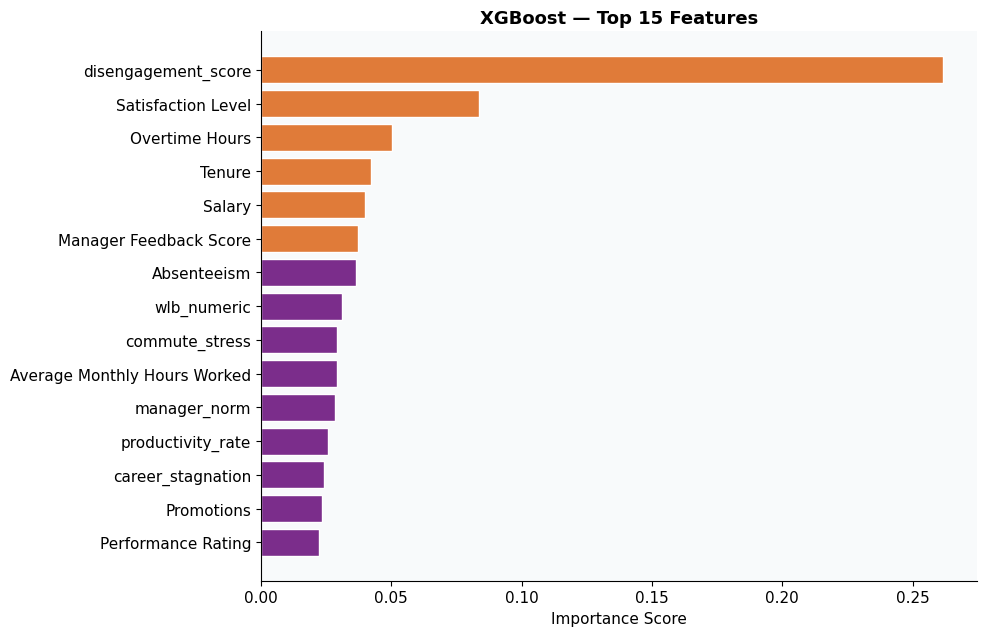

In [20]:
xgb_imp = (pd.DataFrame({'Feature':X_train.columns,'Importance':xgb.feature_importances_})
           .sort_values('Importance', ascending=True).tail(15))
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(xgb_imp['Feature'], xgb_imp['Importance'],
        color=[ORANGE if i>=len(xgb_imp)-6 else PURPLE for i in range(len(xgb_imp))],
        edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost — Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 10a. Hyperparameter Tuning — XGBoost

**Why tune XGBoost separately?**  
XGBoost has more hyperparameters than Random Forest — each one interacts with the others.  
A tuned XGBoost (learning_rate × n_estimators × regularisation) often significantly  
outperforms a default one on imbalanced HR data.

**Key trade-off to understand:**  
Lower `learning_rate` → needs higher `n_estimators` but generalises better.  
Higher `reg_alpha/lambda` → penalises complexity → reduces overfit.


In [21]:
# ── Hyperparameter Tuning — XGBoost ─────────────────────────────

xgb_param_grid = {
    'n_estimators':      [100, 200, 300, 400],    # boosting rounds
    'max_depth':         [3, 4, 5, 6],            # shallower = less overfit
    'learning_rate':     [0.01, 0.05, 0.1, 0.2], # shrinkage per step
    'subsample':         [0.6, 0.7, 0.8, 0.9],   # row sampling per tree
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],   # feature sampling per tree
    'reg_alpha':         [0, 0.1, 0.5, 1.0],      # L1 regularisation
    'reg_lambda':        [0.5, 1.0, 1.5, 2.0],   # L2 regularisation
}

xgb_search = RandomizedSearchCV(
    estimator   = XGBClassifier(
                      scale_pos_weight = scale_pos,  # handle imbalance
                      eval_metric      = 'auc',
                      random_state     = 42,
                      verbosity        = 0),
    param_distributions = xgb_param_grid,
    n_iter      = 10,           # 30 random combinations
    scoring     = 'roc_auc',
    cv          = skf,          # same StratifiedKFold as RF
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)

print("🔍 Searching best XGBoost parameters (15 random combinations × 3-fold CV)...")
xgb_search.fit(X_train, y_train)

print(f"\n Best parameters found:")
for param, val in sorted(xgb_search.best_params_.items()):
    print(f"   {param:25s}: {val}")
print(f"\n   Best CV AUC (during search): {xgb_search.best_score_:.4f}")


🔍 Searching best XGBoost parameters (15 random combinations × 3-fold CV)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Best parameters found:
   colsample_bytree         : 0.9
   learning_rate            : 0.05
   max_depth                : 3
   n_estimators             : 200
   reg_alpha                : 0.5
   reg_lambda               : 1.5
   subsample                : 0.8

   Best CV AUC (during search): 0.9275


In [22]:
# ── Evaluate tuned XGBoost vs default ────────────────────────────
xgb_tuned     = xgb_search.best_estimator_
xgb_tuned_res = evaluate('XGBoost (Tuned)', xgb_tuned,
                           X_train, y_train, X_test, y_test)

# Before / After comparison
print("\n" + "─"*50)
print("  Tuning Impact Summary — XGBoost")
print("─"*50)
print(f"  {'Metric':<22} {'Default':>10} {'Tuned':>10} {'Change':>10}")
print("─"*50)

default_xgb_pred = xgb.predict(X_test)
tuned_xgb_pred   = xgb_tuned.predict(X_test)

xgb_metrics = [
    ('AUC (test)',       xgb_res['AUC_test'],                      xgb_tuned_res['AUC_test']),
    ('AUC (5-fold CV)', xgb_res['AUC_cv'],                        xgb_tuned_res['AUC_cv']),
    ('Recall (Churn)',  recall_score(y_test, default_xgb_pred),   recall_score(y_test, tuned_xgb_pred)),
    ('F1 (Churn)',      f1_score(y_test, default_xgb_pred),       f1_score(y_test, tuned_xgb_pred)),
]
for name, def_val, tun_val in xgb_metrics:
    delta = tun_val - def_val
    arrow = '↑' if delta > 0 else '↓' if delta < 0 else '→'
    print(f"  {name:<22} {def_val:>10.4f} {tun_val:>10.4f} {arrow} {abs(delta):>7.4f}")
print("─"*50)



  XGBoost (Tuned)
  ROC-AUC (test)      : 0.9274
  ROC-AUC (5-fold CV) : 0.9287

              precision    recall  f1-score   support

    Retained       0.96      0.82      0.89      1600
     Churned       0.55      0.86      0.67       400

    accuracy                           0.83      2000
   macro avg       0.75      0.84      0.78      2000
weighted avg       0.88      0.83      0.84      2000


──────────────────────────────────────────────────
  Tuning Impact Summary — XGBoost
──────────────────────────────────────────────────
  Metric                    Default      Tuned     Change
──────────────────────────────────────────────────
  AUC (test)                 0.9261     0.9274 ↑  0.0013
  AUC (5-fold CV)            0.9276     0.9287 ↑  0.0011
  Recall (Churn)             0.8375     0.8650 ↑  0.0275
  F1 (Churn)                 0.6865     0.6705 ↓  0.0159
──────────────────────────────────────────────────


---
## 11. Model 3 — Stacking Classifier

RF and XGBoost generate probability predictions via 5-fold CV on the training data.
A Logistic Regression meta-model then learns the optimal combination of those predictions —
trusting whichever base model is more reliable in each region of the feature space.


In [23]:
# Use best parameters found during hyperparameter tuning
# (passing best_params_ to fresh unfitted instances — StackingClassifier fits them internally)
base_rf  = RandomForestClassifier(**rf_search.best_params_,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
base_xgb = XGBClassifier(**xgb_search.best_params_,
                          scale_pos_weight=scale_pos,
                          eval_metric='auc',
                          random_state=42, verbosity=0)
print("✅ Stacking will use tuned RF and tuned XGBoost as base models")
meta = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=[('rf', base_rf), ('xgb', base_xgb)],
    final_estimator=meta, cv=5,
    stack_method='predict_proba', passthrough=False, n_jobs=-1)
stk_res = evaluate('Stacking (RF + XGBoost → LogReg)',
                   stacking, X_train, y_train, X_test, y_test)

✅ Stacking will use tuned RF and tuned XGBoost as base models

  Stacking (RF + XGBoost → LogReg)
  ROC-AUC (test)      : 0.9265
  ROC-AUC (5-fold CV) : 0.9285

              precision    recall  f1-score   support

    Retained       0.92      0.92      0.92      1600
     Churned       0.68      0.67      0.68       400

    accuracy                           0.87      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.87      0.87      0.87      2000



In [24]:
# Meta-learner weights
meta_model = stacking.final_estimator_
coefs = meta_model.coef_[0]
feat_names = [e[0] for e in stacking.estimators]
print("Meta-learner — how much it trusts each base model:")
for name, coef in zip(feat_names, coefs):
    print(f"  {name:5s}  probability: {coef:+.4f}  "
          f"({'trust MORE' if coef > 0 else 'trust LESS'})")

Meta-learner — how much it trusts each base model:
  rf     probability: +2.1122  (trust MORE)
  xgb    probability: +4.3223  (trust MORE)


---
## 12. Model Comparison

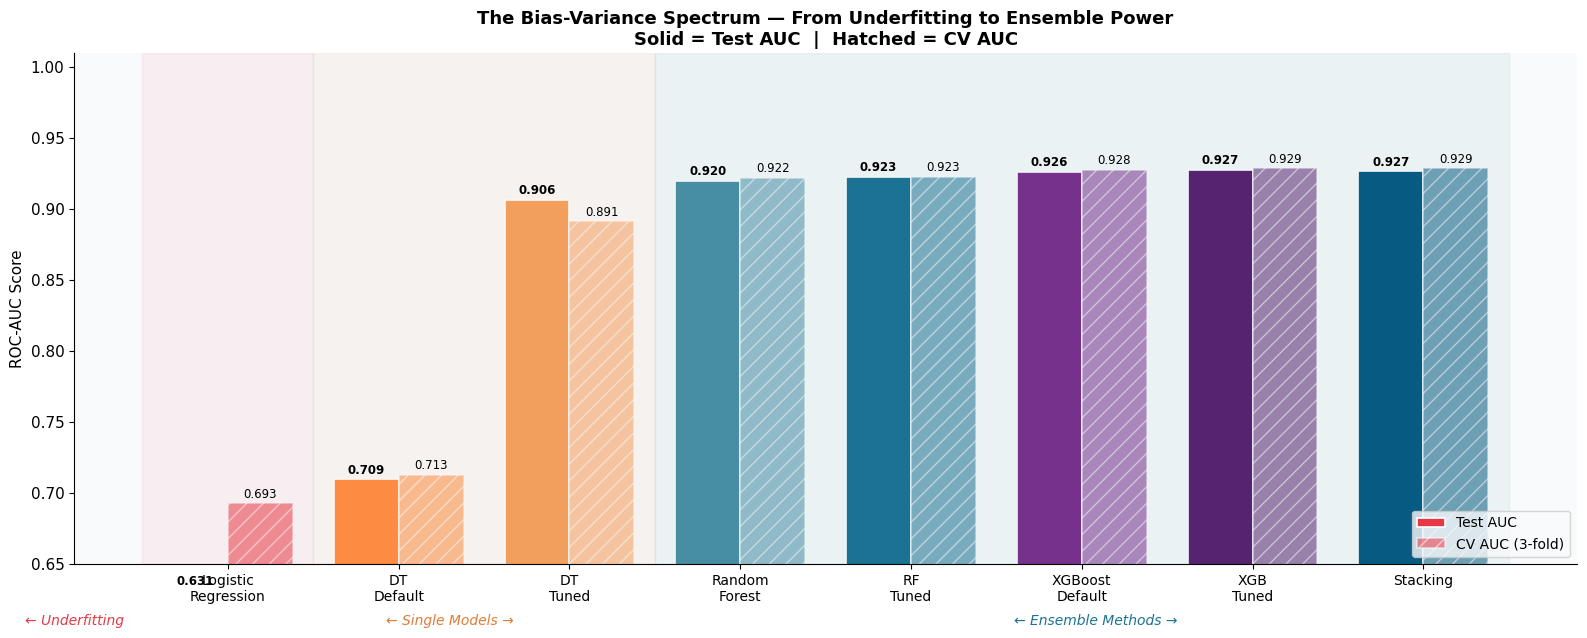

📌 Reading the chart:
   Left (red zone)   : LR — consistent but limited → underfitting
   Middle (orange)   : Single DTs — default overfits, tuned improves
   Right (teal zone) : Ensembles — consistently highest and most stable


In [25]:
# ── Bias-Variance Spectrum — all models in one bar chart ─────────
# This single chart tells the whole story:
# left = underfitting, middle = single model trade-offs, right = ensemble power

all_current = [
    ('Logistic\nRegression', lr_res,          '#E63946'),  # underfit
    ('DT\nDefault',          dt_default_res,  '#FF8C42'),  # overfit
    ('DT\nTuned',            dt_tuned_res,    '#F4A261'),  # single-model best
    ('Random\nForest',       rf_res,          '#4A90A4'),  # ensemble
    ('RF\nTuned',            rf_tuned_res,    '#1C7293'),  # ensemble tuned
    ('XGBoost\nDefault',     xgb_res,         '#7B2D8B'),  # boosting
    ('XGB\nTuned',           xgb_tuned_res,   '#5A1F6E'),  # boosting tuned
    ('Stacking',              stk_res,         '#065A82'),  # meta-ensemble
]

names     = [m[0] for m in all_current]
test_aucs = [m[1]['AUC_test'] for m in all_current]
cv_aucs   = [m[1]['AUC_cv']   for m in all_current]
colors    = [m[2]             for m in all_current]

x = np.arange(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 6.5))
b1 = ax.bar(x - w/2, test_aucs, w, label='Test AUC',    color=colors, edgecolor='white', lw=1.2)
b2 = ax.bar(x + w/2, cv_aucs,   w, label='CV AUC (3-fold)',
            color=colors, edgecolor='white', lw=1.2, alpha=0.55, hatch='//')

for bar, val in zip(b1, test_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(b2, cv_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

# Zone labels - positioned outside the plot area
ax.axvspan(-0.5, 0.5,  alpha=0.06, color=RED,    label='_nolegend_')
ax.axvspan( 0.5, 2.5,  alpha=0.06, color=ORANGE, label='_nolegend_')
ax.axvspan( 2.5, 7.5,  alpha=0.06, color=TEAL,   label='_nolegend_')

# Position zone labels using transform coordinates (outside plot area)
ax.text(0.0,  -0.12, '← Underfitting', ha='center', fontsize=10,  color=RED,   style='italic', transform=ax.transAxes)
ax.text(0.25, -0.12, '← Single Models →', ha='center', fontsize=10, color=ORANGE, style='italic', transform=ax.transAxes)
ax.text(0.68, -0.12, '← Ensemble Methods →', ha='center', fontsize=10, color=TEAL,  style='italic', transform=ax.transAxes)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('ROC-AUC Score', fontsize=11)
ax.set_ylim(0.65, 1.01)  # Lowered from 0.82 to 0.65 to show DT Default
ax.set_title('The Bias-Variance Spectrum — From Underfitting to Ensemble Power\n'
             'Solid = Test AUC  |  Hatched = CV AUC',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

print("📌 Reading the chart:")
print("   Left (red zone)   : LR — consistent but limited → underfitting")
print("   Middle (orange)   : Single DTs — default overfits, tuned improves")
print("   Right (teal zone) : Ensembles — consistently highest and most stable")

In [26]:
rows = []
for res in [lr_res, dt_default_res, dt_tuned_res,
            rf_res, rf_tuned_res,
            xgb_res, xgb_tuned_res, stk_res]:
    pred = res['model'].predict(X_test)
    rows.append({'Model':res['Model'],
                 'ROC-AUC (test)': f"{res['AUC_test']:.4f}",
                 'ROC-AUC (CV)':   f"{res['AUC_cv']:.4f}",
                 'Recall  (Churn)':f"{recall_score(y_test,pred):.4f}",
                 'Precision':      f"{precision_score(y_test,pred):.4f}",
                 'F1 (Churn)':     f"{f1_score(y_test,pred):.4f}"})
print(pd.DataFrame(rows).to_string(index=False))

                           Model ROC-AUC (test) ROC-AUC (CV) Recall  (Churn) Precision F1 (Churn)
             Logistic Regression         0.6307       0.6927          0.0475    0.4222     0.0854
         Decision Tree (Default)         0.7094       0.7127          0.5125    0.5775     0.5430
           Decision Tree (Tuned)         0.9064       0.8912          0.8775    0.4821     0.6223
       Random Forest (300 trees)         0.9198       0.9220          0.7375    0.6399     0.6852
           Random Forest (Tuned)         0.9228       0.9226          0.7950    0.6092     0.6898
             XGBoost (300 trees)         0.9261       0.9276          0.8375    0.5816     0.6865
                 XGBoost (Tuned)         0.9274       0.9287          0.8650    0.5475     0.6705
Stacking (RF + XGBoost → LogReg)         0.9265       0.9285          0.6725    0.6845     0.6784


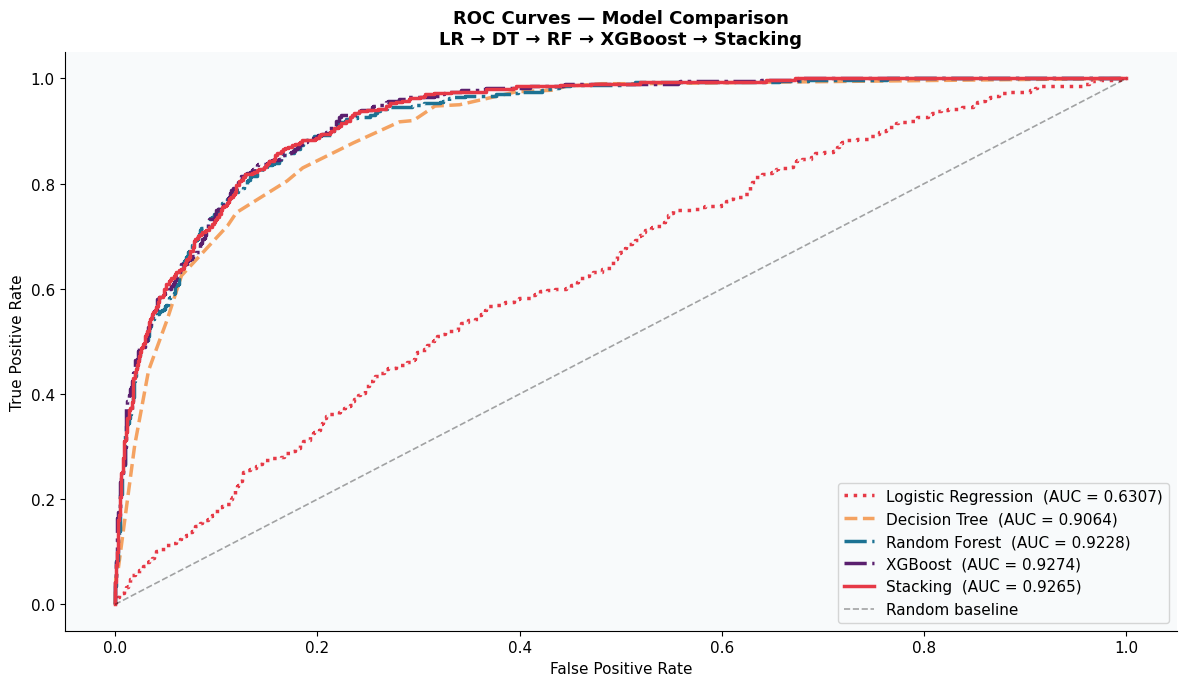

In [27]:
# ROC Curves
fig, ax = plt.subplots(figsize=(12, 7))
for res, label, color, ls in [
    (lr_res,           'Logistic Regression', '#E63946', ':'),
    (dt_tuned_res,     'Decision Tree',        '#F4A261', '--'),
    (rf_tuned_res,     'Random Forest',        '#1C7293', '-.'),
    (xgb_tuned_res,    'XGBoost',              '#5A1F6E', '-.'),
    (stk_res,          'Stacking',             RED,      '-')]:
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    auc = roc_auc_score(y_test, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5, ls=ls,
            label=f"{label}  (AUC = {auc:.4f})")
ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.35,label='Random baseline')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison\nLR → DT → RF → XGBoost → Stacking', 
              fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

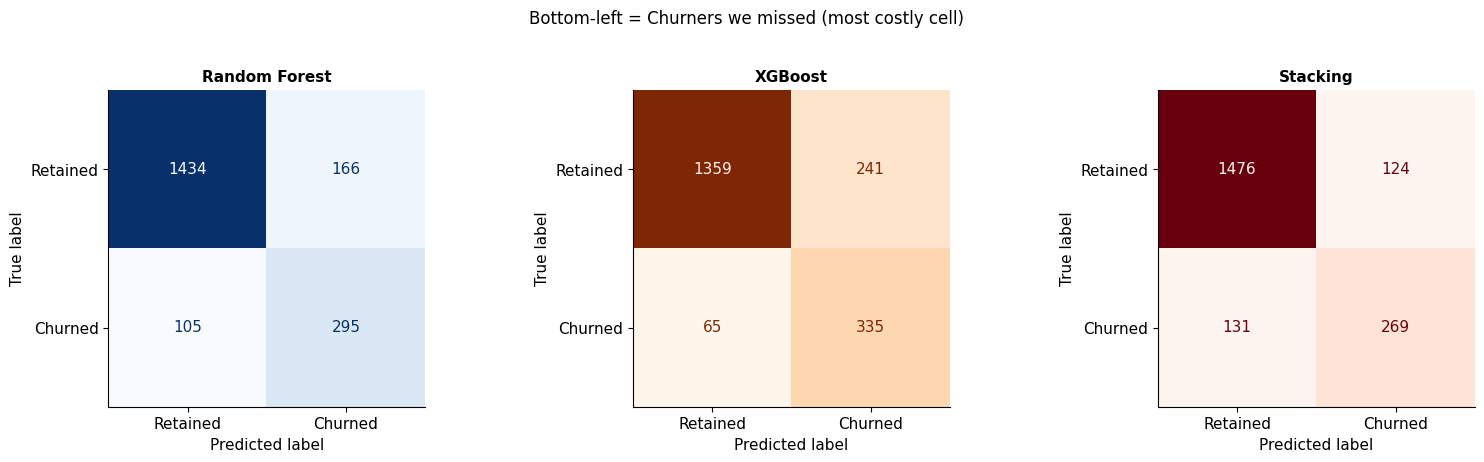

In [28]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, res, cmap in zip(axes,
    [rf_res, xgb_res, stk_res], ['Blues','Oranges','Reds']):
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(res['Model'].split('(')[0].strip(), fontsize=11, fontweight='bold')
plt.suptitle('Bottom-left = Churners we missed (most costly cell)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Business Takeaways

### Top churn drivers — what the models agree on

| Rank | Driver | Pattern Found | HR Action |
|---|---|---|---|
| 1 | **Satisfaction Level** | Churned employees score ~0.3 lower on average | Monthly pulse surveys. Act within 30 days of low scores. |
| 2 | **Manager Feedback Score** | ~1.5 points lower for churners | Manager effectiveness coaching. 360° reviews. |
| 3 | **Work-Life Balance** | Poor WLB employees churn at 2.5× Excellent | Audit team workloads. Enforce limits on sustained overtime. |
| 4 | **Tenure (new hires & mid-career)** | U-shaped — years 1–2 and 6–9 are highest risk | Structured 90-day onboarding. Career review at 5-year mark. |
| 5 | **Salary** | Below-median salary = higher churn probability | Annual market-rate benchmarking for below-median earners. |
| 6 | **Overtime Hours** | High overtime is a leading indicator | Flag employees consistently above 35 OT hours/month. |
| 7 | **Promotions** | Not-promoted employees churn ~30% more | Even lateral moves or title changes reduce exit probability. |

### Which model to use when

| Scenario | Best choice | Why |
|---|---|---|
| Weekly at-risk dashboard | **XGBoost** | Best Recall — catches the most leavers |
| Annual talent review ranking | **Stacking** | Best overall AUC — most reliable ranking |
| Manager explainability meeting | **Random Forest** | Feature importances are directly readable |

### The highest-risk employee profile

> Someone who scores below **0.30 on satisfaction**, below **4.0 on manager feedback**,  
> has **Poor work-life balance**, **no promotion in 5+ years**, and **overtime > 35 hours/month**.  
> This combination warrants an immediate 1-on-1 conversation — before they have already decided to leave.


In [29]:
print("=== Notebook Complete ===")
print(f"Employees trained on : {len(X_train):,}")
print(f"Employees tested on  : {len(X_test):,}")
print(f"Features used        : {X.shape[1]}")
print()
for res in [lr_res, dt_default_res, dt_tuned_res,
            rf_res, rf_tuned_res,
            xgb_res, xgb_tuned_res, stk_res]:
    pred = res['model'].predict(X_test)
    print(f"{res['Model'][:40]:40s}  AUC={res['AUC_test']:.4f}"
          f"  Recall={recall_score(y_test,pred):.3f}"
          f"  F1={f1_score(y_test,pred):.3f}")

=== Notebook Complete ===
Employees trained on : 8,000
Employees tested on  : 2,000
Features used        : 28

Logistic Regression                       AUC=0.6307  Recall=0.048  F1=0.085
Decision Tree (Default)                   AUC=0.7094  Recall=0.512  F1=0.543
Decision Tree (Tuned)                     AUC=0.9064  Recall=0.877  F1=0.622
Random Forest (300 trees)                 AUC=0.9198  Recall=0.738  F1=0.685
Random Forest (Tuned)                     AUC=0.9228  Recall=0.795  F1=0.690
XGBoost (300 trees)                       AUC=0.9261  Recall=0.838  F1=0.686
XGBoost (Tuned)                           AUC=0.9274  Recall=0.865  F1=0.671
Stacking (RF + XGBoost → LogReg)          AUC=0.9265  Recall=0.672  F1=0.678
